# Initialize

In [15]:
import mitsuba as mi
mi.set_variant('scalar_spectral')

In [16]:
import util
import importlib
importlib.reload(util)
import pandas as pd
import cv2
import numpy as np
import drjit as dr

from matplotlib import pyplot as plt

# Render Image

Model id = 0
Blood fraction of Papillary Dermis material = 0.025
Blood fraction of Upper Blood Dermis material = 0.2
Blood fraction of Reticular Dermis material = 0.0075
Blood fraction of Deep Blood Dermis material = 0.2
Melanosome fraction of Epidermis material = 0.01
Light name =  diffuse



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


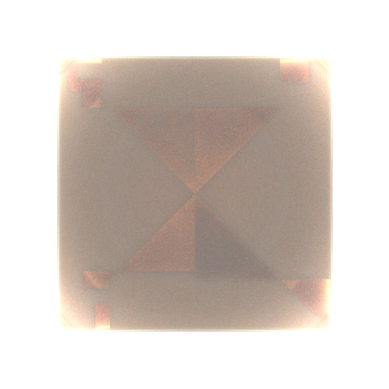

Model id = 0
Blood fraction of Papillary Dermis material = 0.025
Blood fraction of Upper Blood Dermis material = 0.2
Blood fraction of Reticular Dermis material = 0.0075
Blood fraction of Deep Blood Dermis material = 0.2
Melanosome fraction of Epidermis material = 0.05
Light name =  diffuse



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


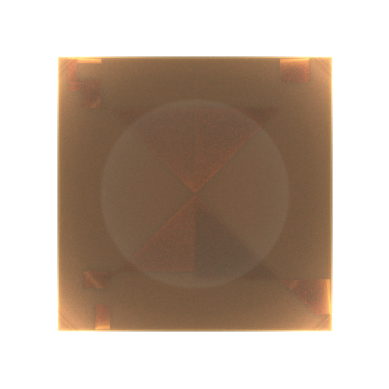

In [17]:
#Define parameters
mel=[0.01, 0.05]
for i in mel : 
    id_model= 0
    id_fB_papillary=0.025   #Choice between 0.011,0.015,0.020,0.025
    id_fb_upper_blood=0.2 #Choice between 0.02,0.03,0.04,0.05
    id_fb_reticular=0.0075   #Choice between 0.0075,0.01,0.012,0.014
    id_fb_deep_blood=0.2  #Choice between 0.01,0.02,0.03,0.04
    id_mel=i
    id_light=19
    # get material names
    sel_lightName = util.get_materials_names(id_light)


    # get render camera
    cam_top = util.get_sensor(20)

    # render image
    scene_ref = util.render_image(id_model,id_fB_papillary, id_fb_upper_blood, id_fb_reticular, id_fb_deep_blood, id_mel, sel_lightName, IMAGE=True)
    ref_image = mi.render(scene_ref, sensor=cam_top, spp=1024)

    plt.imshow(ref_image)
    plt.axis('off')
    plt.show()

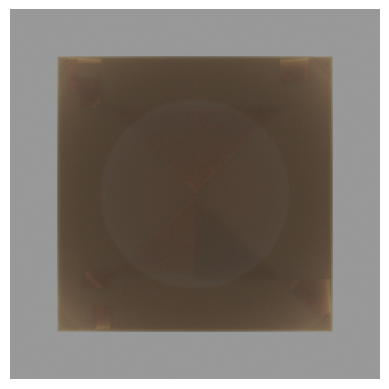

In [14]:
img = np.array(ref_image)

# simple Reinhard tonemap
img = img / (1 + img)

plt.imshow(np.clip(img, 0, 1))
plt.axis('off')
plt.show()